# Conditional Linear Gaussian models

| | | |
|-|-|-|
|[ ![Creative Commons License](images/cc4.png)](http://creativecommons.org/licenses/by-nc/4.0/) |[ ![aGrUM](images/logoAgrum.png)](https://pyagrum.gitlab.io) |[ ![interactive online version](images/atbinder.svg)](https://mybinder.org/v2/gl/agrumery%2FaGrUM/forBinder?urlpath=%2Fdoc%2Ftree%2Fwrappers%2Fpyagrum%2Fdoc%2Fsphinx%2Fnotebooks%2F72-PyModels_CLG.ipynb)

In [1]:
import pyagrum as gum
import pyagrum.lib.notebook as gnb
import pyagrum.lib.bn_vs_bn as gcm

import pyagrum.clg as gclg
import pyagrum.clg.notebook as gclgnb

## Build a CLG model 

### From scratch

Suppose we want to build a CLG with these specifications $A={\cal N}(5,1)$, $B={\cal N}(4,3)$ and $C=2.A+3.B+{\cal N}(3,2)$

In [2]:
model = gclg.CLG()
model.add(gclg.GaussianVariable("A", 5, 1))
model.add(gclg.GaussianVariable("C", 3, 2))
model.add(gclg.GaussianVariable("B", 4, 3))
model.addArc("A", "C", 2)
model.addArc("B", "C", 3)
model

CLG{nodes: 3, arcs: 2, parameters: 8}

### From SEM (Structural Equation Model)

We can create a Conditional Linear Gaussian Bayesian networ(CLG model) using a SEM-like syntax. 

`A = 4.5 [0.3]` means that the mean of the distribution for Gaussian random variable A is 4.5 and ist standard deviation is 0.3. 

`B = 3 + 0.8F [0.3]` means that the mean of the distribution for the Gaussian random variable B is 3 and the standard deviation is 0.3.  

`pyagrum.CLG.SEM` is a set of static methods to manipulate this kind of SEM.


In [3]:
sem2 = """
A=4.5 [0.3] # comments are allowed
F=7 [0.5]
B=3 + 1.2F [0.3]
C=9 +  2A + 1.5B [0.6]
D=9 + C + F[0.7]
E=9 + D [0.9]
"""

model2 = gclg.SEM.toclg(sem2)

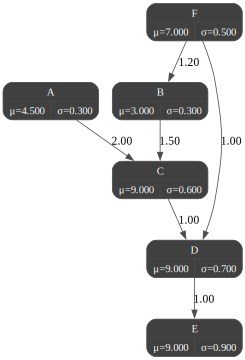

In [4]:
gnb.show(model2)

One can of course build the SEM from a CLG using `pyagrum.CLG.SEM.tosem`  :

In [5]:
gnb.flow.row(
  model,
  "<pre><div align='left'>" + gclg.SEM.tosem(model) + "</div></pre>",
  captions=["the first CLG model", "the SEM from the CLG"],
)

And this SEM allows of course input/output format for CLG

In [6]:
gclg.SEM.saveCLG(model2, "out/model2.sem")

print("=== file content ===")
with open("out/model2.sem", "r") as file:
  for line in file.readlines():
    print(line, end="")
print("====================")

=== file content ===
F=7.0[0.5]
B=3.0+1.2F[0.3]
A=4.5[0.3]
C=9.0+2.0A+1.5B[0.6]
D=9.0+F+C[0.7]
E=9.0+D[0.9]


In [7]:
model3 = gclg.SEM.loadCLG("out/model2.sem")
gnb.sideBySide(model2, model3, captions=["saved model", "loaded model"])

## input/output with pickle for CLG

In [8]:
import pickle

with open("out/testCLG.pkl", "bw") as f:
  pickle.dump(model3, f)
model3

CLG{nodes: 6, arcs: 6, parameters: 18}

In [9]:
with open("out/testCLG.pkl", "br") as f:
  copyModel3 = pickle.load(f)
copyModel3

NotFound: '0' not found in the CLG.

CLG{nodes: 6, arcs: 6, parameters: 18}

## Exact or approximated Inference

### Exact inference : Variable Elimination

Compute some posterior using difference exact inference

In [10]:
ie = gclg.CLGVariableElimination(model2)
ie.updateEvidence({"D": 3})

print(ie.posterior("A"))
print(ie.posterior("B"))
print(ie.posterior("C"))
print(ie.posterior("D"))
print(ie.posterior("E"))
print(ie.posterior("F"))


v = ie.posterior("E")
print(v)
print(f"  - mean(E|D=3)={v.mu()}")
print(f"  - stdev(E|D=3)={v.sigma()}")

A:1.9327650111193468[0.28353638852446156]
B:-2.5058561897702[0.41002992170553515]
C:3.9722757598220895[0.5657771474513671]
D:3[0]
E:12.0[0.9]
F:-2.9836916234247597[0.32358490464094586]
E:12.0[0.9]
  - mean(E|D=3)=12.0
  - stdev(E|D=3)=0.9


In [11]:
gnb.sideBySide(
  model2,
  gclgnb.getInference(model2, evs={"D": 3}, size="3!"),
  gclgnb.getInference(model2, evs={"D": 3, "F": 1}),
  captions=["The CLG", "First inference", "Second inference"],
)

### Approximated inference : MonteCarlo Sampling

When the model is too complex for exact infernece, we can use forward sampling to generate 5000 samples from the original CLG model. 

In [12]:
fs = gclg.ForwardSampling(model2)
fs.makeSample(5000).tocsv("./out/model2.csv")

We will use the generated database to do learning. But before, we can also compute posterior but without evidence :

In [13]:
ie = gclg.CLGVariableElimination(model2)
print("| 'Exact' inference                        | Results from sampling                    |")
print("|------------------------------------------|------------------------------------------|")
for i in model2.names():
  print(f"| {str(ie.posterior(i)):40} | {str(gclg.GaussianVariable(i, fs.mean_sample(i), fs.stddev_sample(i))):40} |")

| 'Exact' inference                        | Results from sampling                    |
|------------------------------------------|------------------------------------------|
| A:4.499999999999998[0.3]                 | A:4.50378189487088[0.3001837831691623]   |
| F:7.000000000000008[0.5000000000000002]  | F:6.992011324008499[0.49489865794540727] |
| B:11.399999999999999[0.6708203932499367] | B:11.391528212168039[0.6633394264077391] |
| C:35.099999999999994[1.3162446581088183] | C:35.09392218376458[1.3080912728608067]  |
| D:51.10000000000002[1.8364367672206963]  | D:51.073000034310205[1.8036536384891917] |
| E:60.100000000000016[2.0451161336217565] | E:60.05937031386245[1.9968173051326337]  |


Now with the generated database and the original model, we can calculate the log-likelihood of the model.

In [14]:
print("log-likelihood w.r.t orignal model : ", model2.logLikelihood("./out/model2.csv"))

log-likelihood w.r.t orignal model :  -22197.75195581369


## Learning a CLG from data

Use the generated database to do our RAvel Learning. This part needs some time to run.

In [15]:
# RAveL learning
learner = gclg.CLGLearner("./out/model2.csv")

We can get the learned_clg model with function learn_clg() which contains structure learning and parameter estimation.

In [16]:
learned_clg = learner.learnCLG()
gnb.sideBySide(model2, learned_clg, captions=["original CLG", "learned CLG"])

Compare the learned model's structure with that of the original model'.

In [17]:
cmp = gcm.GraphicalBNComparator(model2.asDiscreteBN(), learned_clg.asDiscreteBN())
print(f"F-score(original_clg,learned_clg) : {cmp.scores()['fscore']}")

F-score(original_clg,learned_clg) : 0.8


Get the learned model's parameters and compare them with the original model's parameters using the SEM syntax.

In [18]:
gnb.flow.row(
  "<pre><div align='left'>" + gclg.SEM.tosem(model2) + "</div></pre>",
  "<pre><div align='left'>" + gclg.SEM.tosem(learned_clg) + "</div></pre>",
  captions=["original sem", "learned sem"],
)

We can algo do parameter estimation only with function fitParameters() if we already have the structure of the model.

In [19]:
# We can copy the original CLG
copy_original = gclg.CLG(model2)

# RAveL learning again
RAveL_l = gclg.CLGLearner("./out/model2.csv")

# Fit the parameters of the copy clg
RAveL_l.fitParameters(copy_original)

copy_original

CLG{nodes: 6, arcs: 6, parameters: 18}

## Compare two CLG models

We first create two CLG from two SEMs.

In [20]:
# TWO DIFFERENT CLGs

# FIRST CLG
clg1 = gclg.SEM.toclg("""
# hyper parameters
A=4[1]
B=3[5]
C=-2[5]

#equations
D=A[.2] # D is a noisy version of A
E=1+D+2B [2]
F=E+C+B+E [0.001]
""")

# SECOND CLG
clg2 = gclg.SEM.toclg("""
# hyper parameters
A=4[1]
B=3+A[5]
C=-2+2B+A[5]

#equations
D=A[.2] # D is a noisy version of A
E=1+D+2B [2]
F=E+C [0.001]
""")

This cell shows how to have a quick view of the differences 

In [21]:
gnb.flow.row(clg1, clg2, gcm.graphDiff(clg1, clg2), gcm.graphDiffLegend(), gcm.graphDiff(clg2, clg1))

We compare the CLG models.

In [22]:
# We use the F-score to compare the two CLGs
cmp = gcm.GraphicalBNComparator(clg1.asDiscreteBN(), clg1.asDiscreteBN())
print(f"F-score(clg1,clg1) : {cmp.scores()['fscore']}")

cmp = gcm.GraphicalBNComparator(clg1.asDiscreteBN(), clg2.asDiscreteBN())
print(f"F-score(clg1,clg2) : {cmp.scores()['fscore']}")

F-score(clg1,clg1) : 1.0
F-score(clg1,clg2) : 0.7142857142857143


In [23]:
# The complete list of structural scores is :
print("score(clg1,clg2) :")
for score, val in cmp.scores().items():
  print(f"  - {score} : {val}")

score(clg1,clg2) :
  - count : {'tp': 5, 'tn': 6, 'fp': 3, 'fn': 1}
  - recall : 0.8333333333333334
  - precision : 0.625
  - fscore : 0.7142857142857143
  - dist2opt : 0.41036907507483766
  - sid : 3


## Forward Sampling

In [24]:
# We create a simple CLG with 3 variables
clg = gclg.CLG()
# prog=« sigma=2;X=N(5);Y=N(3);Z=X+Y »
A = gclg.GaussianVariable(mu=2, sigma=1, name="A")
B = gclg.GaussianVariable(mu=1, sigma=2, name="B")
C = gclg.GaussianVariable(mu=2, sigma=3, name="C")

idA = clg.add(A)
idB = clg.add(B)
idC = clg.add(C)

clg.addArc(idA, idB, 1.5)
clg.addArc(idB, idC, 0.75)

# We can show it as a graph
original_clg = gclgnb.CLG2dot(clg)
original_clg

In [25]:
fs = gclg.ForwardSampling(clg)
fs.makeSample(10)

In [26]:
print("A's sample_variance: ", fs.variance_sample(0))
print("B's sample_variance: ", fs.variance_sample("B"))
print("C's sample_variance: ", fs.variance_sample(2))

A's sample_variance:  0.7942834750274324
B's sample_variance:  7.172038058791554
C's sample_variance:  17.027821826647124


In [27]:
print("A's sample_mean: ", fs.mean_sample("A"))
print("B's sample_mean: ", fs.mean_sample("B"))
print("C's sample_mean: ", fs.mean_sample("C"))

A's sample_mean:  2.2515248667976087
B's sample_mean:  5.039067863818029
C's sample_mean:  5.805317879982492


In [28]:
fs.toarray()

array([[ 0.82880908,  2.94264749, -0.23916001],
       [ 1.53455952,  2.36517386,  4.5648572 ],
       [ 2.08248304,  5.65125294,  3.73724154],
       [ 3.00291644,  5.11649949, -0.26426065],
       [ 1.99288063,  5.5978706 , 11.59175299],
       [ 3.54396738,  5.93747366, 11.05120107],
       [ 1.02424254,  2.33511397,  5.52827898],
       [ 3.42571912, 10.19953851,  6.66877266],
       [ 2.6470881 ,  8.63821684, 11.02597771],
       [ 2.4325828 ,  1.60689128,  4.38851732]])

In [29]:
# export to dataframe
fs.topandas()

,A,B,C
0,0.828809,2.942647,-0.239160
1,1.534560,2.365174,4.564857
2,2.082483,5.651253,3.737242
3,3.002916,5.116499,-0.264261
4,1.992881,5.597871,11.591753
5,3.543967,5.937474,11.051201
6,1.024243,2.335114,5.528279
7,3.425719,10.199539,6.668773
8,2.647088,8.638217,11.025978
9,2.432583,1.606891,4.388517


In [30]:
# export to csv
fs.makeSample(10000)
fs.tocsv("./out/samples.csv")

## PC-algorithm & Parameter Estimation

The module allows to investigale more deeply into the learning algorithm.

We first create a random CLG model with 5 variables.

In [31]:
# Create a new random CLG
clg = gclg.randomCLG(nb_variables=5, names="ABCDE")

# Display the CLG
print(clg)

CLG{nodes: 5, arcs: 6, parameters: 16}


We then do the Forward Sampling and CLGLearner.

In [32]:
n = 20  # n is the selected values of MC number n in n-MCERA
K = 10000  # K is the list of selected values of number of samples
Delta = 0.05  # Delta is the FWER we want to control

# Sample generation
fs = gclg.ForwardSampling(clg)
fs.makeSample(K).tocsv("./out/clg.csv")

# Learning
RAveL_l = gclg.CLGLearner("./out/clg.csv", n_sample=n, fwer_delta=Delta)

We use the PC algorithme to learn the structure of the model.

In [33]:
# Use the PC algorithm to get the skeleton
C = RAveL_l.PC_algorithm(order=clg.nodes(), verbose=False)
print("The final skeleton is:\n", C)

The final skeleton is:
 {0: set(), 1: set(), 2: {0, 1, 3, 4}, 3: set(), 4: {3}}


In [34]:
# Create a Mixedgraph to display the skeleton
RAveL_MixGraph = gum.MixedGraph()

# Add variables
for i in range(len(clg.names())):
  RAveL_MixGraph.addNodeWithId(i)
  RAveL_MixGraph.setName(i, clg.variable(i).name())

# Add arcs and edges
for father, kids in C.items():
  for kid in kids:
    if father in C[kid]:
      RAveL_MixGraph.addEdge(father, kid)
    else:
      RAveL_MixGraph.addArc(father, kid)

RAveL_MixGraph

(pyagrum.MixedGraph@0x7f5b28000) {0<B>,1<E>,2<A>,3<D>,4<C>} , {2->1,2->3,4->3,2->0,2->4} , {}

In [35]:
# Create a BN with the same structure as the CLG
bn = clg.asDiscreteBN()

# Compare the result above with the EssentialGraph
Real_EssentialGraph = gum.EssentialGraph(bn)

Real_EssentialGraph

<pyagrum.pyagrum.EssentialGraph; proxy of <Swig Object of type 'gum::EssentialGraph *' at 0x116528770> >

In [36]:
# create a CLG from the skeleton of PC algorithm
clg_PC = gclg.CLG()
for node in clg.nodes():
  clg_PC.add(clg.variable(node))
for father, kids in C.items():
  for kid in kids:
    clg_PC.addArc(father, kid)

# Compare the structure of the created CLG and the original CLG
print(f"F-score : {clg.CompareStructure(clg_PC)}")

F-score : 0.9090909090909091


We can also do the parameter learning.

In [37]:
id2mu, id2sigma, arc2coef = RAveL_l.estimate_parameters(C)

for node in clg.nodes():
  print(f"Real Value: node {node} : mu = {clg.variable(node)._mu}, sigma = {clg.variable(node)._sigma}")
  print(f"Estimation: node {node} : mu = {id2mu[node]}, sigma = {id2sigma[node]}")


for arc in clg.arcs():
  print(f"Real Value: arc {arc} : coef = {clg.coefArc(*arc)}")
  print(f"Estimation: arc {arc} : coef = {(arc2coef[arc] if arc in arc2coef else '-')}")

Real Value: node 0 : mu = 2.152698603217572, sigma = 8.97707725523249
Estimation: node 0 : mu = 2.2930221453352218, sigma = 8.994864373527925
Real Value: node 1 : mu = 2.1805350863277333, sigma = 8.92100247059852
Estimation: node 1 : mu = 2.2027955247254454, sigma = 8.869352392248626
Real Value: node 2 : mu = 3.2440605388719455, sigma = 4.93749628411477
Estimation: node 2 : mu = 3.2571732619890645, sigma = 4.9586506431506665
Real Value: node 3 : mu = 2.918694087435912, sigma = 2.820291968602466
Estimation: node 3 : mu = 2.886625989662207, sigma = 2.8112145061623313
Real Value: node 4 : mu = 3.007906768900039, sigma = 8.672772209832385
Estimation: node 4 : mu = -8.633713197510204, sigma = 45.87850209082002
Real Value: arc (2, 3) : coef = 9.107873551902161
Estimation: arc (2, 3) : coef = 9.074314632370777
Real Value: arc (2, 4) : coef = 9.250373413034287
Estimation: arc (2, 4) : coef = -35.14209969655224
Real Value: arc (0, 4) : coef = -5.009765585451545
Estimation: arc (0, 4) : coef = -